# Visualize how target and distractor streams are represented through model hierarchy

#### Use similar approach to https://www.biorxiv.org/content/10.1101/2023.08.04.551888v1.full.pdf

In [1]:
import numpy as np 
import pickle 
import h5py
from scipy import stats
from tqdm.auto import tqdm
from pathlib import Path 
import torch 
import sklearn 
from sklearn.decomposition import PCA
from sklearn.manifold import MDS 
%matplotlib inline
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# Get model activation files 

out_dir = Path('binaural_model_attn_stage_reps/')
# paths = list(out_dir.glob('*model_activations_0dB.h5'))

# path  = Path("binaural_model_attn_stage_reps/word_task_half_co_loc_v07/word_task_half_co_loc_v07_model_activations_0dB.h5")
# path  = Path("/om2/user/imgriff/projects/torch_2_aud_attn/binaural_model_attn_stage_reps/word_task_half_co_loc_v07_model_activations_0dB_w_cues.h5")
path  = Path("binaural_model_attn_stage_reps/word_task_half_co_loc_v07/word_task_half_co_loc_v07_model_activations_0dB_w_cues_v2.h5")

In [3]:
out_dir

PosixPath('binaural_model_attn_stage_reps')

## Set up steps
1) PCA on streams per layer (10-used, run scree to find)
2) Pearson dissimilary for rdm (sounds x sounds of 1 - pearson's r)
3) MDS to 2D (sounds x 2)

#### To plot in 3D add x coord as layer number - connect across layers with lines 

In [4]:
acts =  h5py.File(path, 'r')
print(acts.keys())
layer_names = [key.split("_mixture")[0] for key in acts.keys() if "mixture" in key and 'acc' not in key]
print(layer_names)
print(len(layer_names))
acts.close()

<KeysViewHDF5 ['cochleagram_bg', 'cochleagram_cue', 'cochleagram_fg', 'cochleagram_mixture', 'conv_block_0_bg', 'conv_block_0_bg_no_cue', 'conv_block_0_cue', 'conv_block_0_fg', 'conv_block_0_fg_no_cue', 'conv_block_0_mixture', 'conv_block_0_mixture_no_cue', 'conv_block_1_bg', 'conv_block_1_bg_no_cue', 'conv_block_1_cue', 'conv_block_1_fg', 'conv_block_1_fg_no_cue', 'conv_block_1_mixture', 'conv_block_1_mixture_no_cue', 'conv_block_2_bg', 'conv_block_2_bg_no_cue', 'conv_block_2_cue', 'conv_block_2_fg', 'conv_block_2_fg_no_cue', 'conv_block_2_mixture', 'conv_block_2_mixture_no_cue', 'conv_block_3_bg', 'conv_block_3_bg_no_cue', 'conv_block_3_cue', 'conv_block_3_fg', 'conv_block_3_fg_no_cue', 'conv_block_3_mixture', 'conv_block_3_mixture_no_cue', 'conv_block_4_bg', 'conv_block_4_bg_no_cue', 'conv_block_4_cue', 'conv_block_4_fg', 'conv_block_4_fg_no_cue', 'conv_block_4_mixture', 'conv_block_4_mixture_no_cue', 'conv_block_5_bg', 'conv_block_5_bg_no_cue', 'conv_block_5_cue', 'conv_block_5_fg'

In [34]:
### Demon on fc layer - are smallest 
np.random.seed(0)
make_plots = True

# wanted_layers = ['cochleagram', 'conv_block_2',  'conv_block_3', 'conv_block_6', 'relufc']

acts =  h5py.File(path, 'r')
print(acts.keys())
layer_names = [key.split("_mixture")[0] for key in acts.keys() if "mixture" in key and 'acc' not in key and 'no' not in key]
print(layer_names)
print(len(layer_names))

### Test method that doesn't compute full covariance matrix
n_to_use = 100
# get mixture acts 
# layer = layer_names[-1]
n_components = 10

all_layer_pc_acts = []
labels = []
layer_idx = {}
for layer in tqdm(layer_names):
    # mixture_acts = acts[f"{layer}_mixture"][:n_to_use, :]
    if layer != 'relufc':
        cue_acts = acts[f"{layer}_cue"][:n_to_use, :]
    mixture_acts = acts[f"{layer}_mixture"][:n_to_use, :]
    target_acts = acts[f"{layer}_fg"][:n_to_use, :]
    distractor_acts = acts[f"{layer}_bg"][:n_to_use, :]
    if layer != 'cochleagram':
        mixture_acts_no_attn = acts[f"{layer}_mixture_no_cue"][:n_to_use, :]
        target_acts_no_attn = acts[f"{layer}_fg_no_cue"][:n_to_use, :]
        distractor_acts_no_attn = acts[f"{layer}_bg_no_cue"][:n_to_use, :]

    # stack for joint analysis
    if layer == 'relufc':
        all_acts = np.vstack([mixture_acts, target_acts, distractor_acts, mixture_acts_no_attn, target_acts_no_attn, distractor_acts_no_attn])
        labels.append(np.concatenate([[split]*n_to_use for split in ['mixture', 'target', 'distractor', 'mixture_no_attn', 'target_no_attn', 'distractor_no_attn']]))

    elif layer == 'cochleagram':
        all_acts = np.vstack([cue_acts, mixture_acts, target_acts, distractor_acts])
        labels.append(np.concatenate([[split]*n_to_use for split in ['cue', 'mixture', 'target', 'distractor']]))

    else:
        all_acts = np.vstack([cue_acts, mixture_acts, target_acts, distractor_acts, mixture_acts_no_attn, target_acts_no_attn, distractor_acts_no_attn])
        labels.append(np.concatenate([[split]*n_to_use for split in ['cue', 'mixture', 'target', 'distractor', 'mixture_no_attn', 'target_no_attn', 'distractor_no_attn']]))

    # de-mean all_acts
    all_acts = all_acts - all_acts.mean(axis=0) # , keepdims=True)
    layer_idx[layer] = np.arange(all_acts.shape[0])

    # labels = np.array(["cue"]*n_to_use + ["mixture"]*n_to_use )#+ ["mixture"]*n_to_use)

    # ## Run PCA on all_acts - find number of components to explain 80% variance
    # pca = PCA()
    # pca.fit(all_acts)
    # # plot explained variance scree plot as cumulative
    # if make_plots:
    #     plt.figure(figsize=(4, 3))
    #     plt.plot(pca.explained_variance_ratio_.cumsum())
    #     # add lines for 80% and 95% explained variance
    #     plt.axhline(0.8, color='r', linestyle='--')
    #     plt.axhline(0.95, color='r', linestyle='--')
    #     plt.xlim(0, 20)
    #     plt.ylabel("Explained variance")
    #     plt.xlabel("Number of components")
    #     plt.show()

    # get number of components to explain 80% variance
    # n_components = np.where(pca.explained_variance_ratio_.cumsum() > 0.9)[0][0]
    # print("N components for 80% variance explained: ", n_components)
    # get variance explained by 10 components
    # print("Variance explained by 10 components: ", pca.explained_variance_ratio_[:10].sum())
    # project data onto n_components
    pca = PCA(n_components=n_components, random_state=0, copy=False)
    pca_acts = pca.fit_transform(all_acts)
    print(f"PCA activations shape: {pca_acts.shape}")
    all_layer_pc_acts.append(pca_acts)
    
labels = np.concatenate(labels)
acts.close()

<KeysViewHDF5 ['cochleagram_bg', 'cochleagram_cue', 'cochleagram_fg', 'cochleagram_mixture', 'conv_block_0_bg', 'conv_block_0_bg_no_cue', 'conv_block_0_cue', 'conv_block_0_fg', 'conv_block_0_fg_no_cue', 'conv_block_0_mixture', 'conv_block_0_mixture_no_cue', 'conv_block_1_bg', 'conv_block_1_bg_no_cue', 'conv_block_1_cue', 'conv_block_1_fg', 'conv_block_1_fg_no_cue', 'conv_block_1_mixture', 'conv_block_1_mixture_no_cue', 'conv_block_2_bg', 'conv_block_2_bg_no_cue', 'conv_block_2_cue', 'conv_block_2_fg', 'conv_block_2_fg_no_cue', 'conv_block_2_mixture', 'conv_block_2_mixture_no_cue', 'conv_block_3_bg', 'conv_block_3_bg_no_cue', 'conv_block_3_cue', 'conv_block_3_fg', 'conv_block_3_fg_no_cue', 'conv_block_3_mixture', 'conv_block_3_mixture_no_cue', 'conv_block_4_bg', 'conv_block_4_bg_no_cue', 'conv_block_4_cue', 'conv_block_4_fg', 'conv_block_4_fg_no_cue', 'conv_block_4_mixture', 'conv_block_4_mixture_no_cue', 'conv_block_5_bg', 'conv_block_5_bg_no_cue', 'conv_block_5_cue', 'conv_block_5_fg'

 11%|█         | 1/9 [00:19<02:34, 19.32s/it]

PCA activations shape: (400, 10)


: 

: 

: 

In [6]:
# # save components for each layer as h5 file
# out_file = Path("binaural_model_attn_stage_reps/word_task_half_co_loc_v07/word_task_half_co_loc_v07_model_activations_0dB_pca_acts_all_signals.h5")
# with h5py.File(out_file, 'w') as f:
#     # save layer names
#     f.create_dataset("layer_names", data=np.array(layer_names, dtype='S'))
#     # save labels and pca_acts for each layer
#     for i, layer in enumerate(layer_names):
#         # separate into cue and background
#         cue_acts = all_layer_pc_acts[i][:n_to_use, :]
#         mixture_acts = all_layer_pc_acts[i][n_to_use:2*n_to_use, :]
#         target_acts = all_layer_pc_acts[i][2*n_to_use:3*n_to_use, :]
#         distractor_acts = all_layer_pc_acts[i][3*n_to_use:, :]
#         f.create_dataset(f"{layer}_cue_pcs", data=cue_acts.astype('float32'))
#         f.create_dataset(f"{layer}_mixture_pcs", data=mixture_acts.astype('float32'))
#         f.create_dataset(f"{layer}_target_pcs", data=target_acts.astype('float32'))
#         f.create_dataset(f"{layer}_distractor_pcs", data=distractor_acts.astype('float32'))

(3100, 3100)


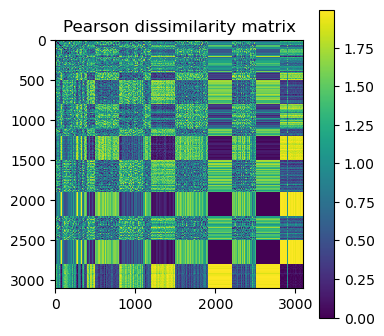

In [ ]:
# run MDS to get 2D representation
# get Pearson dissimilarity matrix comparing target to mixture and distractor to mixture (1 - Pearson correlation; 0 = identical, higher = more dissimilar)

pca_acts = np.vstack(all_layer_pc_acts)

# pca_mixtures = np.vstack([pca_acts[n_to_use*2:]]*2)
dissimilarity = sklearn.metrics.pairwise_distances(pca_acts, metric='correlation')
print(dissimilarity.shape)
if make_plots:
    plt.figure(figsize=(4, 4))
    plt.imshow(dissimilarity, interpolation='none')
    plt.colorbar()
    plt.title("Pearson dissimilarity matrix")



In [ ]:
# save PCA activations 
pca_acts.shape

(3100, 10)

In [ ]:
# run MDS to get 2D representation
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=2, n_init=3, max_iter=1000, verbose=1)
mds_acts = mds.fit_transform(dissimilarity)
# if make_plots:
#     # plot 1st and 2nd dimensions
#     plt.figure(figsize=(4, 4))
#     plt.scatter(mds_acts[:n_to_use, 0], mds_acts[:n_to_use, 1], label="target")
#     plt.scatter(mds_acts[n_to_use:2*n_to_use, 0], mds_acts[n_to_use:2*n_to_use, 1], label="background")
#     # plt.scatter(mds_acts[2*n_to_use:, 0], mds_acts[2*n_to_use:, 1], label="mixture")
#     # move legend outside of plot
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#     plt.title("MDS of PCA activations")

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


breaking at iteration 224 with stress 232895.58474016062
breaking at iteration 307 with stress 232910.36282113998
breaking at iteration 173 with stress 232856.24168861602


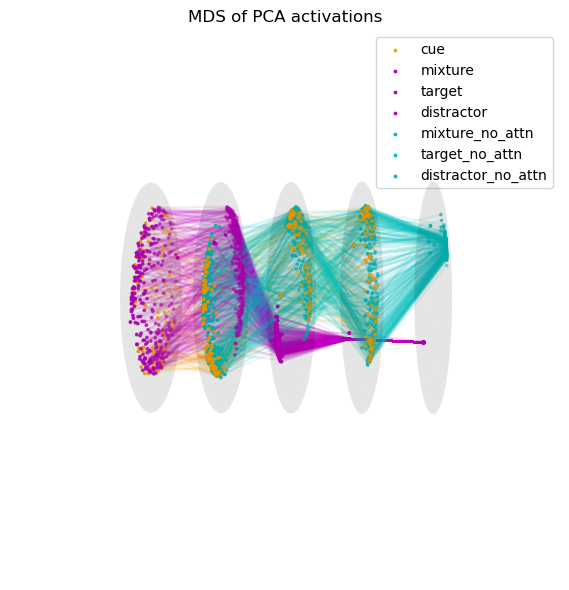

In [ ]:
# Add axis to mds_acts corresponding to the layer names as ints 
layer_names = wanted_layers 

layer_x_coords = np.concatenate([[ix] * len(ix_list) for ix, ix_list in enumerate(layer_idx.values())])

layer_axs_space = layer_x_coords * 6 # 4 is arbitrary, just to space out the layers in the plot
# stream_labels = np.arange((4 * n_to_use * len(layer_names)))
# splits = np.split(stream_labels, 4 * len(layer_names))
# assign every other split to cue and mixture

# # # assign every other split to cue and mixture
# cue_ixs = np.argwhere(labels == 'cue')
# mixture_ixs = np.argwhere(labels == 'mixture')
# target_ixs = np.argwhere(labels == 'target')
# distractor_ixs = np.argwhere(labels == 'distractor')
# mixture_ixs_no_attn = np.argwhere(labels == 'mixture_no_attn')
# target_ixs_no_attn = np.argwhere(labels == 'target_no_attn')
# distractor_ixs_no_attn = np.argwhere(labels == 'distractor_no_attn')
n_layers = len(layer_names)
n_layers_per_stream = {'cue':n_layers - 1,
                    'mixture': n_layers,
                    'target':n_layers,
                    'distractor':n_layers,
                    'mixture_no_attn':n_layers - 1,
                    'target_no_attn':n_layers - 1,
                    'distractor_no_attn':n_layers - 1}
# add to mds_acts
mds_acts_to_plot = np.column_stack([mds_acts, layer_axs_space])

# Plot MDS of PCA activations as 3D array, with x axis as layer index
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
# connect with lines across x axis
ax.elev = 0
ax.azim = 278
plt.axis('off')

color_dict = {label:color for label,color in zip(['cue', 'mixture', 'target', 'distractor', 'mixture_no_attn', 'target_no_attn', 'distractor_no_attn'], ['orange', 'm','m', 'm', 'c', 'c', 'c'])}

for label,color in color_dict.items():
    ixs = np.argwhere(labels == label).flatten()
    ax.scatter(mds_acts_to_plot[ixs, 2], mds_acts_to_plot[ixs, 0], mds_acts_to_plot[ixs, 1], c=color,  s=3, label=label)
    for ix_pairs in ixs.reshape(n_layers_per_stream[label], -1).T:
        ax.plot(mds_acts_to_plot[ix_pairs, 2], mds_acts_to_plot[ix_pairs, 0], mds_acts_to_plot[ix_pairs, 1], c=color, alpha=0.1)

# ax.scatter(mds_acts_to_plot[mixture_ixs, 2], mds_acts_to_plot[mixture_ixs, 0], mds_acts_to_plot[mixture_ixs, 1], c='m', s=3, label="Mixture")
# ax.scatter(mds_acts_to_plot[target_ixs, 2], mds_acts_to_plot[target_ixs, 0], mds_acts_to_plot[target_ixs, 1], c='b', s=3, label="Target")
# ax.scatter(mds_acts_to_plot[distractor_ixs, 2], mds_acts_to_plot[distractor_ixs, 0], mds_acts_to_plot[distractor_ixs, 1], c='r', s=3, label="Distractor")

# for label, color in :
#     for ixs in stream_ixs.reshape(len(layer_names),-1).T:
#         # get cue ixs across layers
#         ax.plot(mds_acts_to_plot[ixs, 2], mds_acts_to_plot[ixs, 0], mds_acts_to_plot[ixs, 1], c=color, alpha=0.1)


# calculate radius of MDS points and draw a circle of this radius around each layer's points. 
# get mean of MDS points
mds_mean = mds_acts_to_plot[:,:2].mean(axis=0)
# get radius
radius = np.linalg.norm(mds_acts_to_plot[:,:2] - mds_mean, axis=1).max() # get max distance from center of ponits 
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
# get y and z for a sphere
y = radius * np.outer(np.sin(u), np.sin(v)) + mds_mean[0]
z = radius * np.outer(np.ones(np.size(u)), np.cos(v)) + mds_mean[1]

for i in np.unique(layer_axs_space):
    x = radius * np.outer(np.cos(u), np.sin(v)) + i
    # plot outline of surface by using only black outline 
    ax.plot_surface(x, y, z, color='k', alpha=0.05)
    
# ax.set_ylabel('MDS 1')
# ax.set_zlabel('MDS 2')
# ax.set_xlabel('Layer index')
# set xtick labels
# ax.set_xticks(np.arange(0, len(layer_names)*6, 6))
# ax.set_xticklabels(layer_names, rotation=90)
plt.title("MDS of PCA activations")
plt.legend()
# plt.xlim(-1,39)

plt.tight_layout()



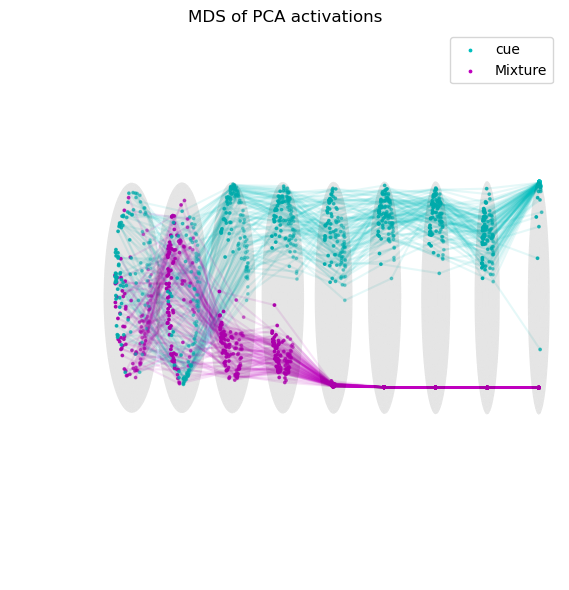

In [ ]:
# # Add axis to mds_acts corresponding to the layer names as ints 

# layer_idx = np.zeros(mds_acts.shape[0], dtype=int)
# for i, layer in enumerate(layer_names):
#     layer_idx[i*(2*n_to_use):(i+1)*(2*n_to_use)] = i

# layer_axs_space = layer_idx * 6 # 4 is arbitrary, just to space out the layers in the plot
# stream_labels = np.arange(2*n_to_use*len(layer_names))
# splits = np.split(stream_labels, 2 * len(layer_names))
# # assign every other split to cue and mixture

# cue_ixs = np.hstack(splits[::2])
# mixture_ixs = np.hstack(splits[1::2])

# # add to mds_acts
# mds_acts_to_plot = np.column_stack([mds_acts, layer_axs_space])

# # Plot MDS of PCA activations as 3D array, with x axis as layer index
# fig = plt.figure(figsize=(9, 6))
# ax = fig.add_subplot(111, projection='3d')
# # connect with lines across x axis
# ax.elev = 0
# ax.azim = 277
# plt.axis('off')


# ax.scatter(mds_acts_to_plot[cue_ixs, 2], mds_acts_to_plot[cue_ixs, 0], mds_acts_to_plot[cue_ixs, 1], c='c',  s=3, label="cue")
# ax.scatter(mds_acts_to_plot[mixture_ixs, 2], mds_acts_to_plot[mixture_ixs, 0], mds_acts_to_plot[mixture_ixs, 1], c='m', s=3, label="Mixture")

# for cue in cue_ixs[:n_to_use]:
#     # get cue ixs across layers
#     ixs = [cue + i*2*n_to_use for i in range(len(layer_names))]
#     ax.plot(mds_acts_to_plot[ixs, 2], mds_acts_to_plot[ixs, 0], mds_acts_to_plot[ixs, 1], c='c', alpha=0.1)

# for distractor in mixture_ixs[:n_to_use]:
#     # get cue ixs across layers
#     ixs = [distractor + i*2*n_to_use for i in range(len(layer_names))]
#     ax.plot(mds_acts_to_plot[ixs, 2], mds_acts_to_plot[ixs, 0], mds_acts_to_plot[ixs, 1], c='m', alpha=0.1)

# # calculate radius of MDS points and draw a circle of this radius around each layer's points. 
# # get mean of MDS points
# mean = mds_acts_to_plot[:,:2].mean(axis=0)
# # get radius
# radius = np.linalg.norm(mds_acts_to_plot[:,:2] - mean, axis=1).max() # get max distance from center of ponits 
# u = np.linspace(0, 2 * np.pi, 100)
# v = np.linspace(0, np.pi, 100)
# # get y and z for a sphere
# y = radius * np.outer(np.sin(u), np.sin(v)) + mean[0]
# z = radius * np.outer(np.ones(np.size(u)), np.cos(v)) + mean[1]

# for i in np.unique(layer_axs_space):
#     x = radius * np.outer(np.cos(u), np.sin(v)) + i
#     # plot outline of surface by using only black outline 
#     ax.plot_surface(x, y, z, color='k', alpha=0.05)
    
# # ax.set_ylabel('MDS 1')
# # ax.set_zlabel('MDS 2')
# # ax.set_xlabel('Layer index')
# # set xtick labels
# # ax.set_xticks(np.arange(0, len(layer_names)*6, 6))
# # ax.set_xticklabels(layer_names, rotation=90)
# plt.title("MDS of PCA activations")
# plt.legend()
# plt.xlim(-1,39)

# plt.tight_layout()



In [ ]:
 mds_acts_to_plot[:,:2].shape

(1800, 2)